## __Visualização dos Dados__

---

##### __Imports__

In [1]:
import pandas as pd

##### __Leitura dos dados e Informações Iniciais__

In [2]:
path_excel = "C:\\Users\\daiki\\OneDrive\\Documentos\\USP\\7 semestre\\CEA\\notebook\\CEA-1\\sipnibancostatafiltrado.xls"
df_excel = pd.read_excel(path_excel)
df = df_excel.copy()

path_dta = 'C:\\Users\\daiki\\OneDrive\\Documentos\\USP\\7 semestre\\CEA\\dados\\sipnibancostatafiltrado.dta'
df_dta = pd.read_stata(path_dta)

In [3]:
rows_excel, cols_excel = df_excel.shape
rows_dta, cols_dta = df_dta.shape

print("Excel:", rows_excel, "linhas e", cols_excel, "colunas")
print("DTA:", rows_dta, "linhas e", cols_dta, "colunas")

Excel: 846 linhas e 61 colunas
DTA: 846 linhas e 61 colunas


#### **Descrição da Variáveis Explicativas**

- idade *(idade_txt, idade_anos)* 
- sexo *(sexo)*
- tempo entre a vacinação e o início do evento *(dt_not/dt_fed - dt_apl)*
- necessidade de internação *()*
- erro de imunização *(cls_ei, cls_erro, cls_eien, cls_fei, cond_ei, cond_oe, cls_eifed, cls_oefed, cond_fd, cond_oefed)*
- lote da vacina *(lote)*

#### **Descrição das Variáveis Respostas**

- Evolução do caso **(evol_num)**
- 

In [5]:
column = "tp_ev"   # <-- Change this to any column name

print("\n Valores possíveis da colunas\n")
print("=" * 50)
print(f"  Column: '{column}'")
print("=" * 50)

# Unique values (no count)
unique_vals = df[column].unique()
print(f"\n📌 Unique values ({len(unique_vals)} total):")
for val in unique_vals:
    print(f"   - {val}")

# Value counts (with frequency)
print(f"\n📊 Value counts (sorted by frequency):")
counts = df[column].value_counts(dropna=False)
for val, count in counts.items():
    
    print(f"   {str(val):<15} {count:>3}")

# Summary stats
print(f"\n📋 Summary:")
print(f"   Total rows       : {len(df)}")
print(f"   Unique values    : {df[column].nunique()}")
print(f"   Missing values   : {df[column].isna().sum()}")
print(f"   Most frequent    : {df[column].mode()[0]}")
print("=" * 50)


 Valores possíveis da colunas

  Column: 'tp_ev'

📌 Unique values (4 total):
   - Não Grave (EANG) - Qualquer outro evento que não esteja incluído nos critéri
   - Erro de Imunização
   - Grave (EAG)
   - Erro de imunização com evento adverso

📊 Value counts (sorted by frequency):
   Não Grave (EANG) - Qualquer outro evento que não esteja incluído nos critéri 450
   Erro de Imunização 357
   Grave (EAG)      35
   Erro de imunização com evento adverso   4

📋 Summary:
   Total rows       : 846
   Unique values    : 4
   Missing values   : 0
   Most frequent    : Não Grave (EANG) - Qualquer outro evento que não esteja incluído nos critéri


In [6]:

# ── 4. (Optional) Explore ALL columns at once ─────────────────────────────────
print("\n\n🔍 Quick overview of ALL columns:\n")
for col in df.columns:
    n_unique = df[col].nunique()
    n_missing = df[col].isna().sum()
    top_val = df[col].mode()[0] if not df[col].mode().empty else "N/A"
    print(f"  [{col}]")
    print(f"    Unique: {n_unique}  |  Missing: {n_missing}  |  Most common: {top_val}")
   # if n_unique <= 10:  # Only show values if there aren't too many
    print(f"    Values: {sorted(df[col].dropna().unique().tolist())}")
    print()




🔍 Quick overview of ALL columns:

  [dt_not]
    Unique: 556  |  Missing: 0  |  Most common: 2020-10-26 00:00:00
    Values: [Timestamp('2018-01-11 00:00:00'), Timestamp('2018-01-18 00:00:00'), Timestamp('2018-01-23 00:00:00'), Timestamp('2018-01-26 00:00:00'), Timestamp('2018-01-30 00:00:00'), Timestamp('2018-01-31 00:00:00'), Timestamp('2018-02-01 00:00:00'), Timestamp('2018-02-02 00:00:00'), Timestamp('2018-02-05 00:00:00'), Timestamp('2018-02-06 00:00:00'), Timestamp('2018-02-20 00:00:00'), Timestamp('2018-02-23 00:00:00'), Timestamp('2018-02-28 00:00:00'), Timestamp('2018-03-13 00:00:00'), Timestamp('2018-03-14 00:00:00'), Timestamp('2018-03-15 00:00:00'), Timestamp('2018-03-19 00:00:00'), Timestamp('2018-03-20 00:00:00'), Timestamp('2018-03-21 00:00:00'), Timestamp('2018-03-23 00:00:00'), Timestamp('2018-03-24 00:00:00'), Timestamp('2018-04-02 00:00:00'), Timestamp('2018-04-03 00:00:00'), Timestamp('2018-04-05 00:00:00'), Timestamp('2018-04-10 00:00:00'), Timestamp('2018-04-13 

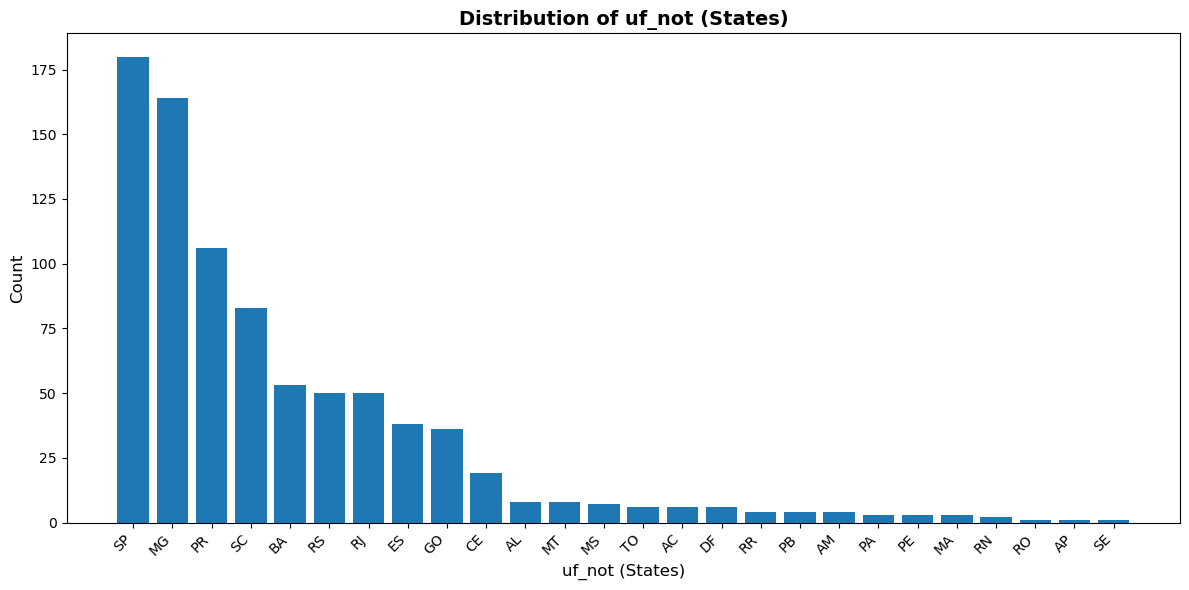

In [10]:
import matplotlib.pyplot as plt

# Count values in uf_not column
uf_counts = df['uf_not'].value_counts().sort_values(ascending=False)

# Create bar graph
plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('uf_not (States)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of uf_not (States)', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

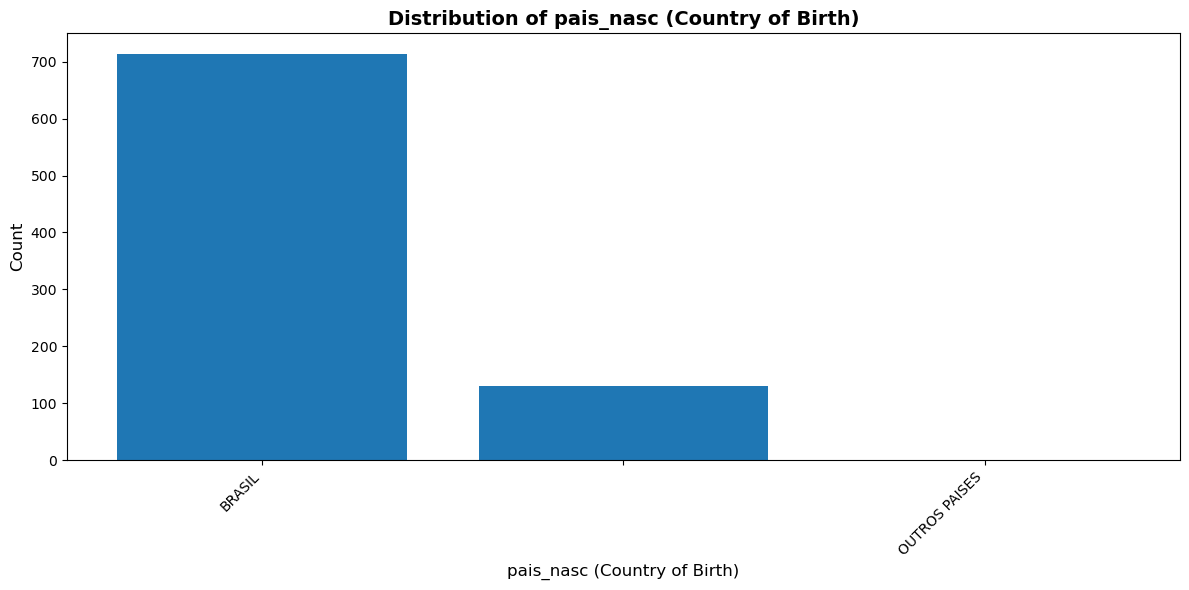

In [15]:
import matplotlib.pyplot as plt

# Count values in pais_nasc column
pais_counts = df['pais_nasc'].value_counts().sort_values(ascending=False)

# Create bar graph
plt.figure(figsize=(12, 6))
plt.bar(range(len(pais_counts)), pais_counts.values)
plt.xlabel('pais_nasc (Country of Birth)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of pais_nasc (Country of Birth)', fontsize=14, fontweight='bold')
plt.xticks(range(len(pais_counts)), pais_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

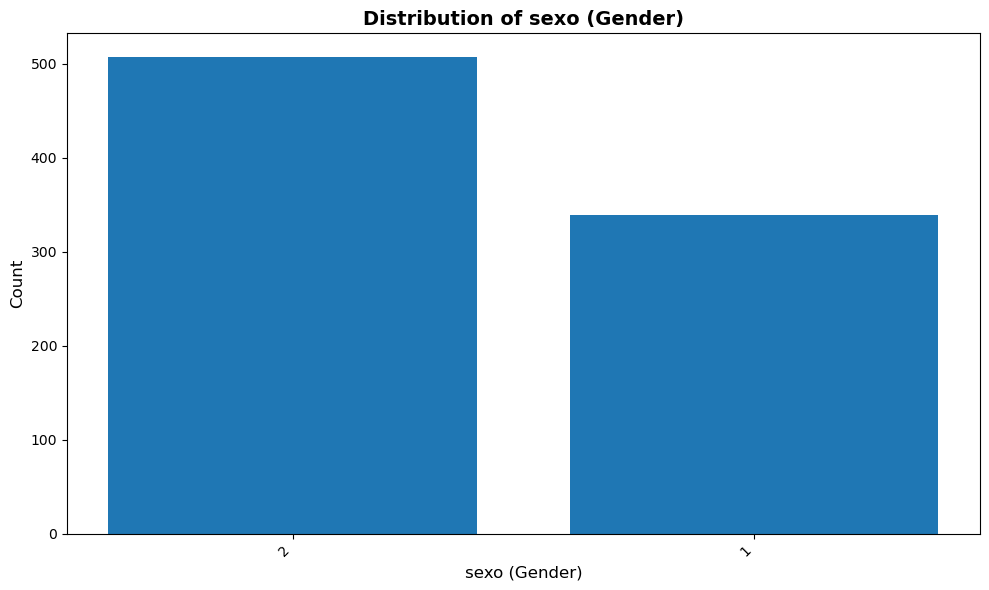

In [17]:
import matplotlib.pyplot as plt

# Count values in sexo column
sexo_counts = df['sexo'].value_counts().sort_values(ascending=False)

# Create bar graph
plt.figure(figsize=(10, 6))
plt.bar(range(len(sexo_counts)), sexo_counts.values)
plt.xlabel('sexo (Gender)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of sexo (Gender)', fontsize=14, fontweight='bold')
plt.xticks(range(len(sexo_counts)), sexo_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


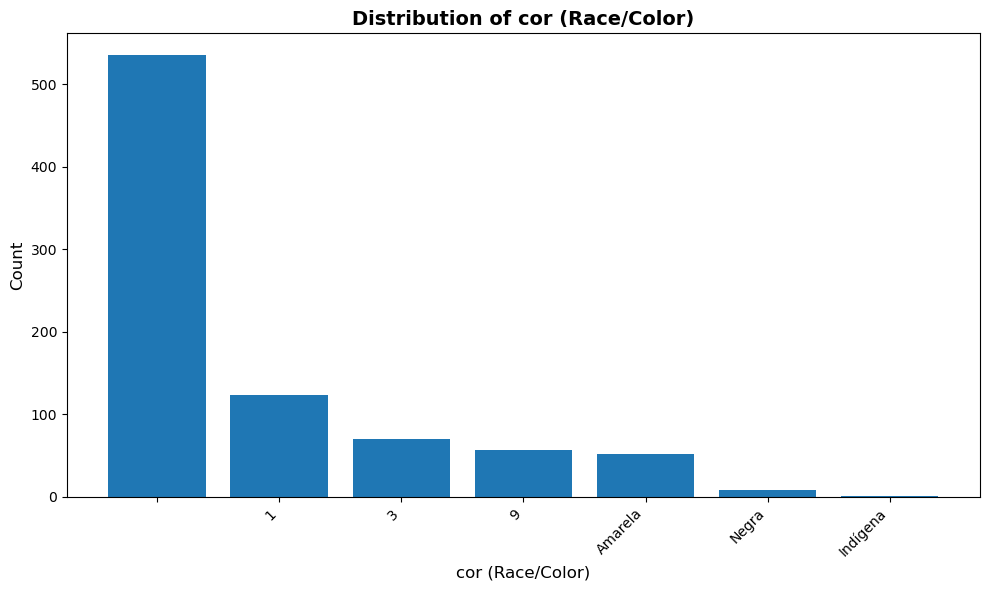

In [20]:
import matplotlib.pyplot as plt

# Count values in cor column
cor_counts = df['cor'].value_counts().sort_values(ascending=False)

# Create bar graph
plt.figure(figsize=(10, 6))
plt.bar(range(len(cor_counts)), cor_counts.values)
plt.xlabel('cor (Race/Color)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of cor (Race/Color)', fontsize=14, fontweight='bold')
plt.xticks(range(len(cor_counts)), cor_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


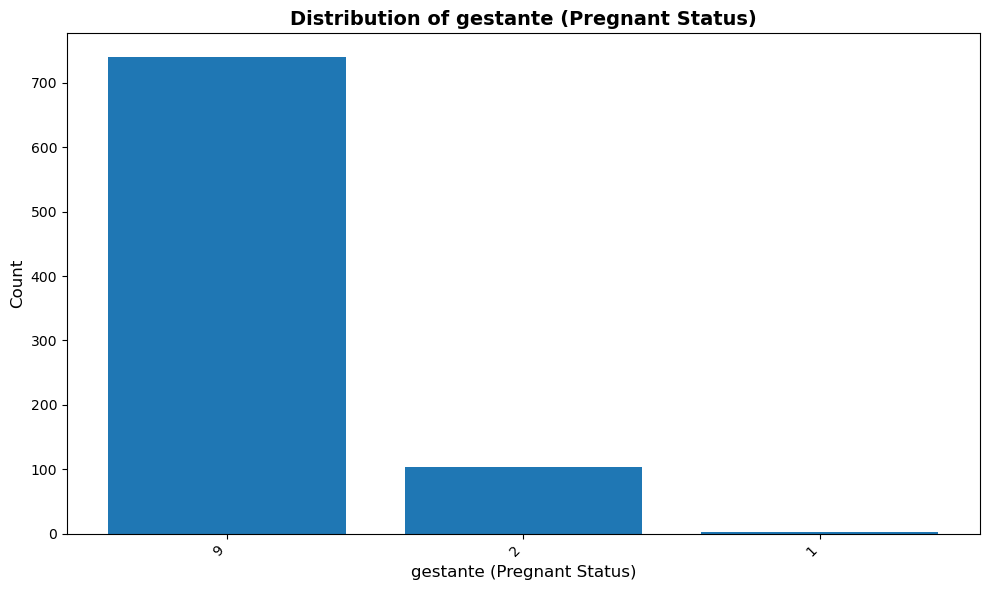

In [21]:
import matplotlib.pyplot as plt

# Count values in gestante column
gestante_counts = df['gestante'].value_counts().sort_values(ascending=False)

# Create bar graph
plt.figure(figsize=(10, 6))
plt.bar(range(len(gestante_counts)), gestante_counts.values)
plt.xlabel('gestante (Pregnant Status)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of gestante (Pregnant Status)', fontsize=14, fontweight='bold')
plt.xticks(range(len(gestante_counts)), gestante_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


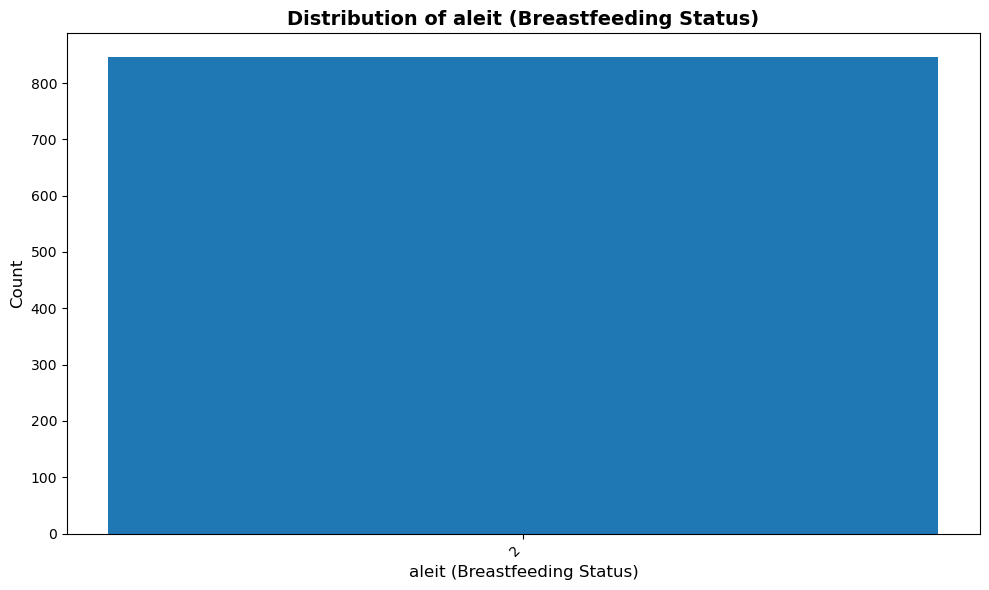

In [22]:
import matplotlib.pyplot as plt

# Count values in aleit column
aleit_counts = df['aleit'].value_counts().sort_values(ascending=False)

# Create bar graph
plt.figure(figsize=(10, 6))
plt.bar(range(len(aleit_counts)), aleit_counts.values)
plt.xlabel('aleit (Breastfeeding Status)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of aleit (Breastfeeding Status)', fontsize=14, fontweight='bold')
plt.xticks(range(len(aleit_counts)), aleit_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()
